## Vuelos diarios
- En este trabajo vamos a usar series de tiempo para predecir la cantodad de vuelos diarios en Reino Unido usando datos desde 2019-2022

## UK daily flights
- In this project we'll be using time series to predict the amount of daily flights in the UK using data from 2019-2022

In [1]:
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset
data = fetch_dataset(name = 'uk_daily_flights')
data.index.name = 'datetime'

╭──────────────────────────────── uk_daily_flights ────────────────────────────────╮
│ Description:                                                                     │
│ Daily number of flights in UK from 02/01/2019 to 23/01/2022.                     │
│                                                                                  │
│ Source:                                                                          │
│ Experimental statistics published as part of the Economic activity and social    │
│ change in the UK, real-time indicators release, Published 27 January 2022. Daily │
│ flight numbers are available in the dashboard provided by the European           │
│ Organisation for the Safety of Air Navigation (EUROCONTROL). https://www.ons.gov │
│ .uk/economy/economicoutputandproductivity/output/bulletins/economicactivityandso │
│ cialchangeintheukrealtimeindicators/latest                                       │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/main/data/uk_daily_flights.csv                                          │
│                                                                                  │
│ Shape: 1118 rows x 1 columns                                                     │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [2]:
data.head

<bound method NDFrame.head of             Number of flights
datetime                     
2019-01-02               5147
2019-01-03               5518
2019-01-04               5588
2019-01-05               4798
2019-01-06               5329
...                       ...
2022-01-19               2084
2022-01-20               2408
2022-01-21               2801
2022-01-22               2361
2022-01-23               2696

[1118 rows x 1 columns]>

In [3]:
data.isnull().sum()

Number of flights    0
dtype: int64

# Entendimiento de datos - Data analysis

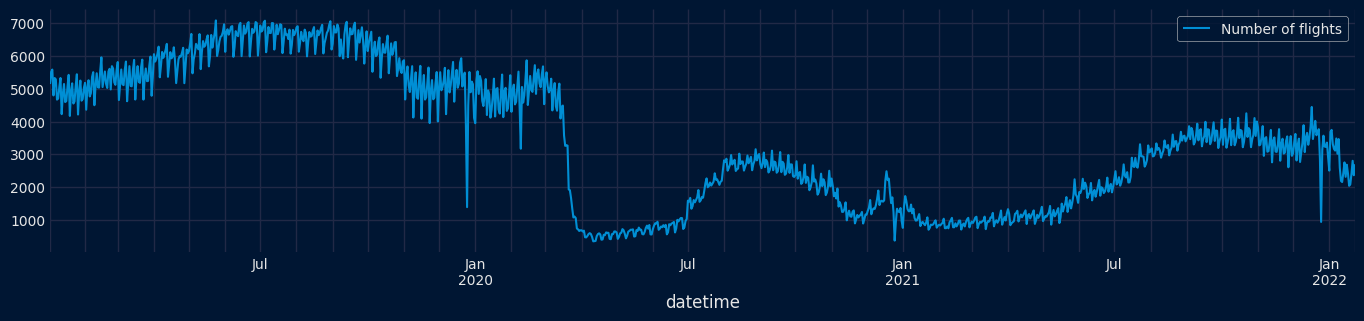

In [4]:
from skforecast.plot import set_dark_theme
set_dark_theme()
fig, ax = plt.subplots(figsize = (15, 3))
data.plot(ax = ax)
ax.legend()
plt.show()

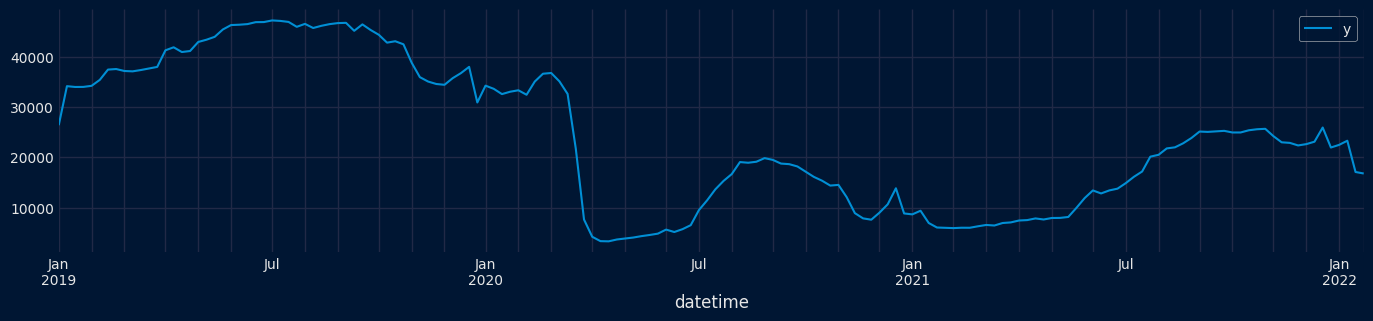

In [5]:
data = data.rename(columns={'Number of flights': 'y'})
data_weekly = data['y'].resample('W').sum()
from skforecast.plot import set_dark_theme
set_dark_theme()
fig, ax = plt.subplots(figsize = (15, 3))
data_weekly.plot(ax = ax)
ax.legend()
plt.show()


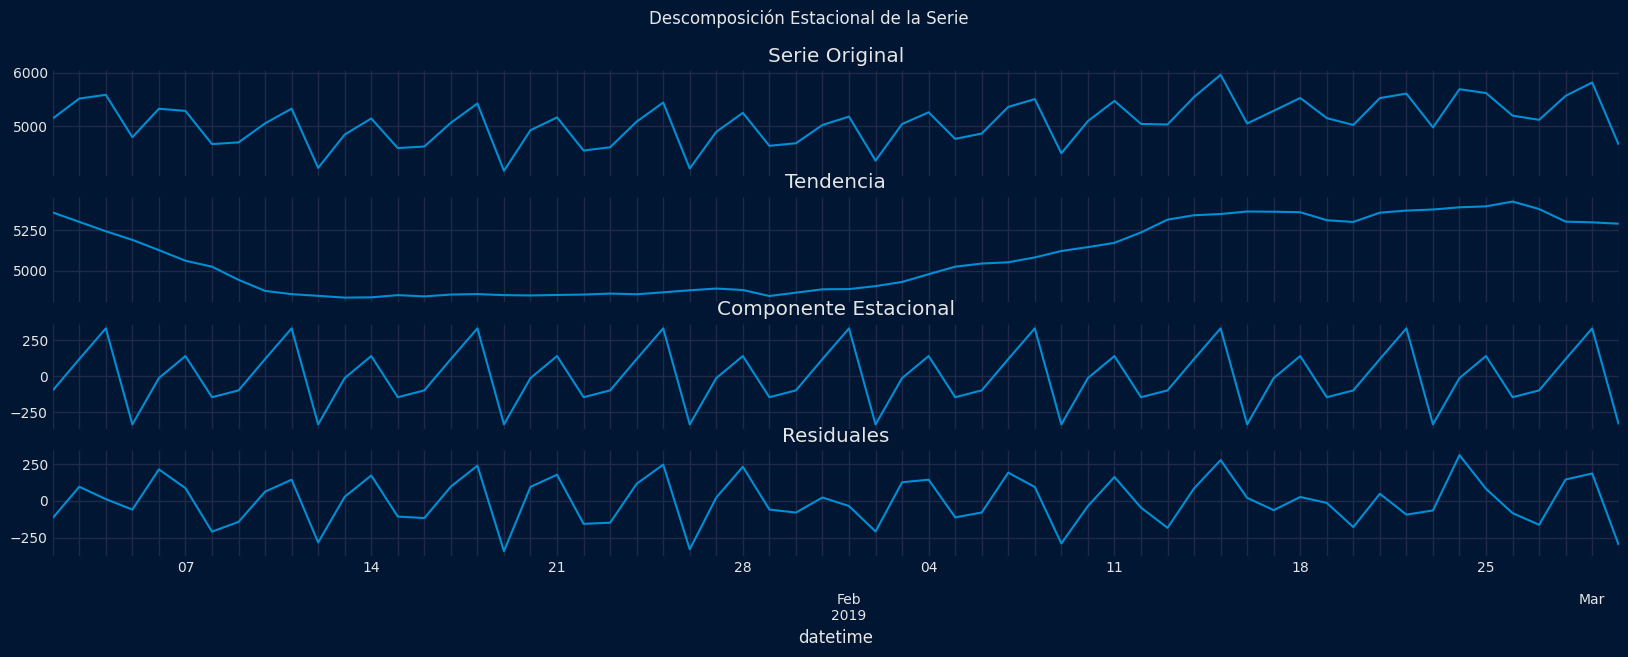

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

res_decompose = seasonal_decompose(data, model='additive', extrapolate_trend='freq')

fig, ax = plt.subplots(4, 1, figsize=(18, 6), sharex=True)

res_decompose.observed.iloc[:60].plot(ax=ax[0])
ax[0].set_title('Serie Original')

res_decompose.trend.iloc[:60].plot(ax=ax[1])
ax[1].set_title('Tendencia')

res_decompose.seasonal.iloc[:60].plot(ax=ax[2])
ax[2].set_title('Componente Estacional')

res_decompose.resid.iloc[:60].plot(ax=ax[3])
ax[3].set_title('Residuales')

fig.suptitle('Descomposición Estacional de la Serie')
plt.show()

In [7]:
#Test de Dickey-Fuller
from statsmodels.tsa.stattools import adfuller
adfuller_result = adfuller(data)
print(f'El estadístico de prueba es: {adfuller_result[0]}, y el valor-p es: {adfuller_result[1]}')
#Si p-value < 0.05 → la serie ES estacionaria ✅
#Si p-value >= 0.05 → la serie NO es estacionaria ❌

El estadístico de prueba es: -1.5864876735142777, y el valor-p es: 0.49037757119970204


# Preparacion de datos - Data preparation

Test de Estacionariedad de Dickey - Fuller
El estadístico de prueba es: -5.4584435910621405 y el valor-p es: 2.550394011597793e-06


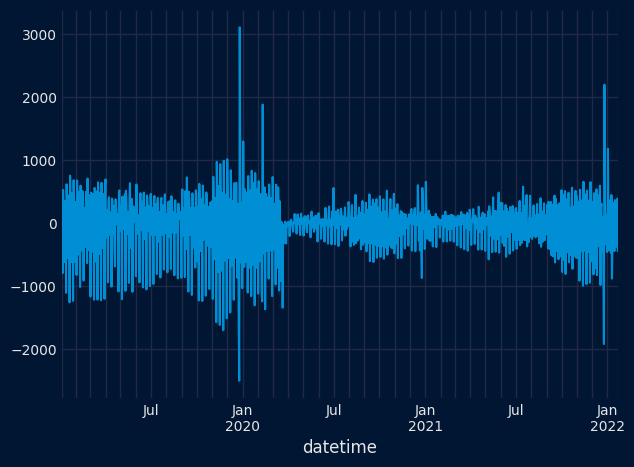

In [8]:
data_diff = data['y'].diff().dropna()
print('Test de Estacionariedad de Dickey - Fuller')
adfuller_result = adfuller(data_diff)
print(f'El estadístico de prueba es: {adfuller_result[0]} y el valor-p es: {adfuller_result[1]}')
data_diff.plot()
plt.show()

In [9]:
#Variable exogena para marcar pandemia

data['pandemia'] = 0
data.loc['2020-03-01': '2020-06-30' , 'pandemia'] = 1

data['recuperacion'] = 0
data.loc['2020-07-01': '2021-04-01', 'recuperacion'] = 1

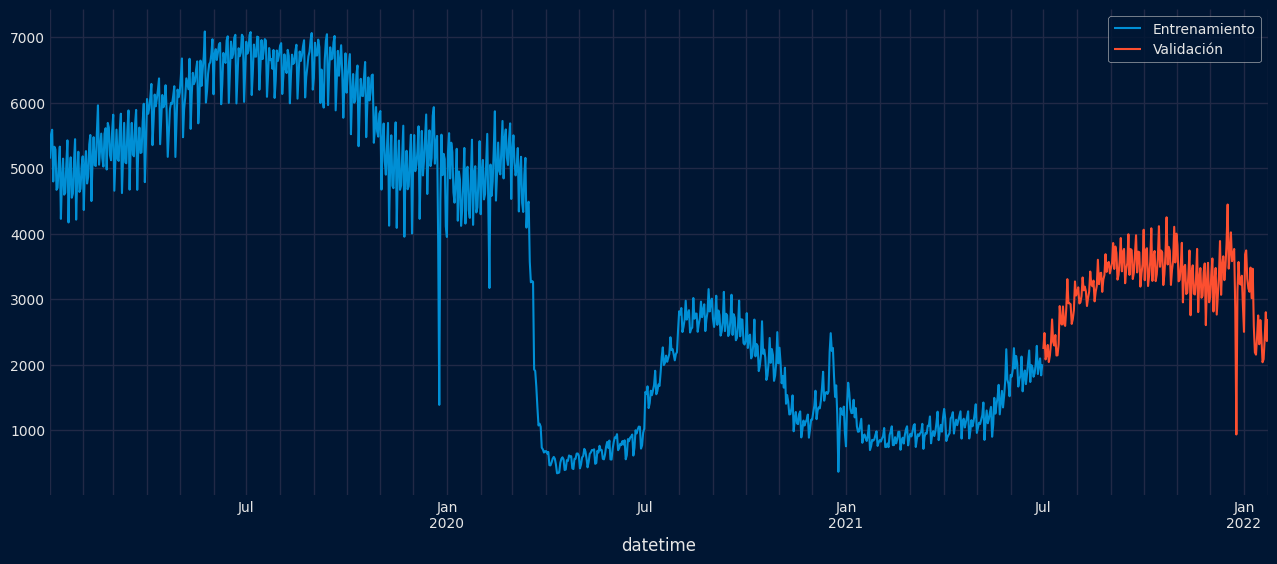

Train: 2019-01-02 00:00:00 hasta 2021-06-30 00:00:00
Validación: 2021-07-01 00:00:00 hasta 2022-01-23 00:00:00
Última fecha train: 2021-06-30 00:00:00
Primera fecha test: 2021-07-01 00:00:00
Primera fecha exog_train: 2019-01-02 00:00:00
Ultima fecha exog_train: 2021-06-30 00:00:00
Primera fecha exog_test: 2021-07-01 00:00:00


In [10]:
end_train = '2021-06-30'

data_train = data['y'].loc[:end_train]
data_test = data['y'].loc[data['y'].index > end_train]
exog_train = data.loc[data_train.index, ['pandemia', 'recuperacion']]
exog_test = data.loc[data_test.index, ['pandemia', 'recuperacion']]

plt.figure(figsize=(14, 6))
data_train.plot(label='Entrenamiento')
data_test.plot(label='Validación')
plt.legend()
plt.show()

print("Train:", data_train.index.min(), "hasta", data_train.index.max())
print("Validación:", data_test.index.min(), "hasta", data_test.index.max())

print("Última fecha train:", data_train.index.max())
print("Primera fecha test:", data_test.index.min())

print("Primera fecha exog_train:", exog_train.index.min())
print("Ultima fecha exog_train:", exog_train.index.max())
print("Primera fecha exog_test:", exog_test.index.min())

# Modelado de datos - Data modeling

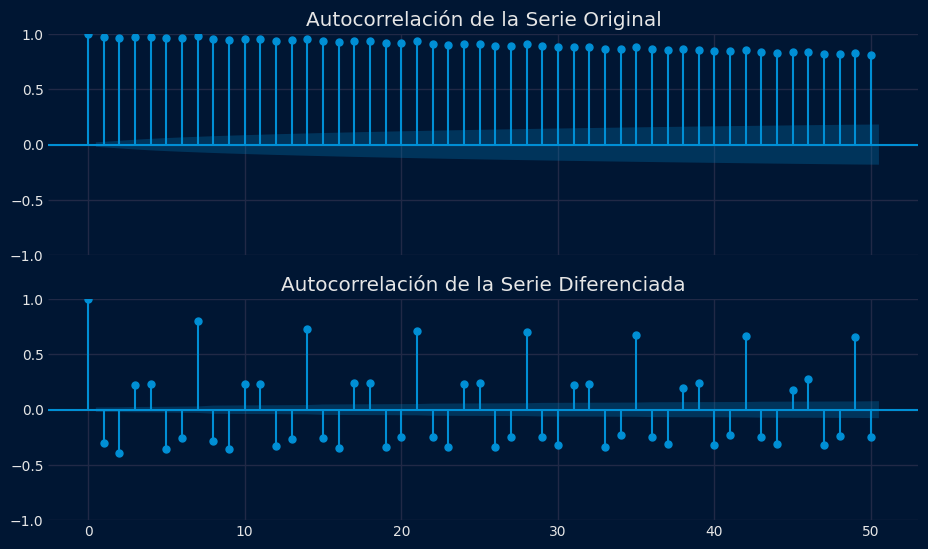

In [11]:
#SARIMAX: SARIMA(p, d, q)(P, D, Q, m)
###Parte no estacional
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#Grafico de Autocorrelación
fig, ax = plt.subplots(2, 1, figsize = (10, 6), sharex = True)
plot_acf(data['y'], ax = ax[0], lags = 50, alpha = 0.5)
ax[0].set_title('Autocorrelación de la Serie Original')
plot_acf(data_diff, ax = ax[1], lags = 50, alpha = 0.5)
ax[1].set_title('Autocorrelación de la Serie Diferenciada')
plt.show()

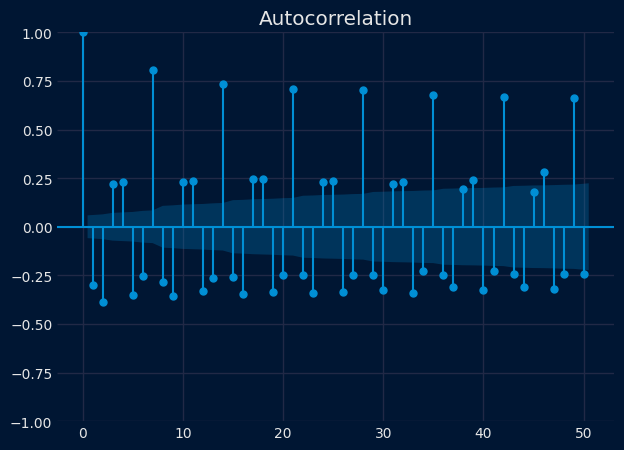

In [12]:
plot_acf(data_diff, lags = 50);
# Me quedo con q=1 o probar con 2. Ademas Q=1 y m=7

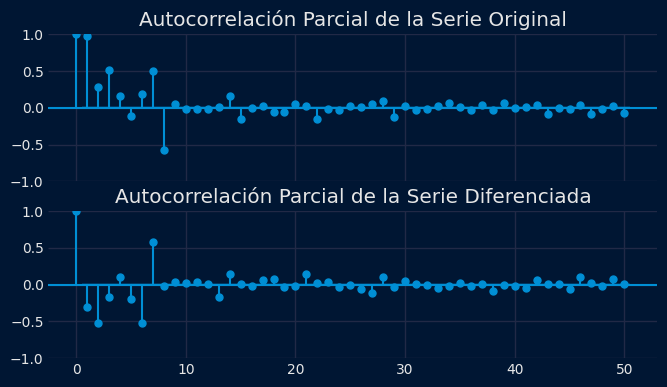

In [13]:
#Grafico de Autocorrelación Parcial
fig, ax = plt.subplots(2, 1, figsize = (7, 4), sharex = True)
plot_pacf(data['y'], ax = ax[0], lags = 50, alpha = 0.5)
ax[0].set_title('Autocorrelación Parcial de la Serie Original')
plot_pacf(data_diff, ax = ax[1], lags = 50, alpha = 0.5)
ax[1].set_title('Autocorrelación Parcial de la Serie Diferenciada')
plt.show()

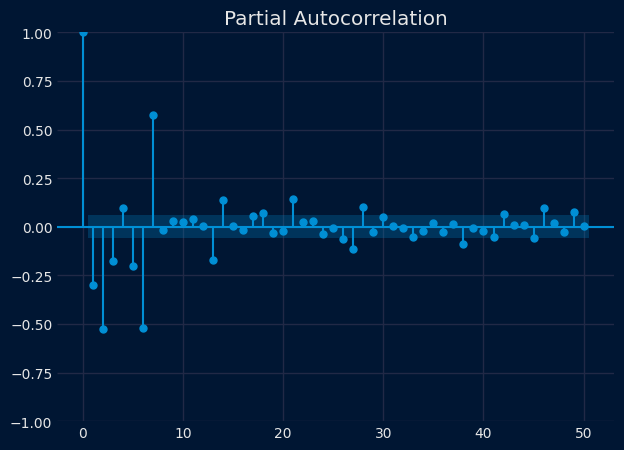

In [14]:
plot_pacf(data_diff, lags = 50);
#Los primeros 2 se ven interesantes entonces probar p=1,2

In [15]:
#Diferenciación Estacional
data_diff_7 = data['y'].diff().diff(7).dropna()
adfuller_result = adfuller(data_diff_7)
print(f'El estadístico de prueba es: {adfuller_result[0]} y el valor-p es: {adfuller_result[1]}')
#d = 1     porque hiciste diff()
#D = 1     porque hiciste diff(7)
#m = 7    porque la estacionalidad es anual en datos mensuales

El estadístico de prueba es: -10.035368188562718 y el valor-p es: 1.545752264706255e-17


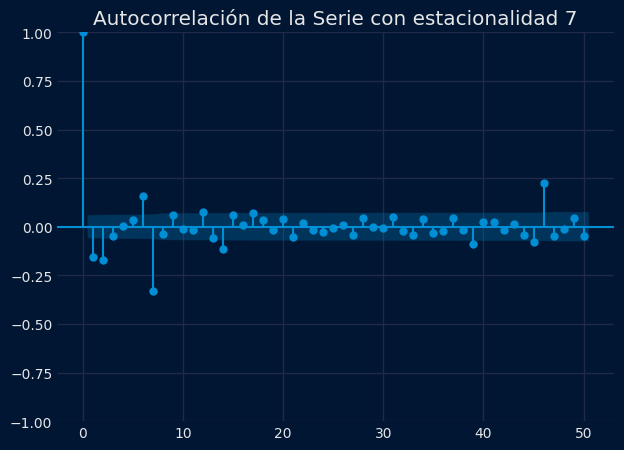

In [16]:
#Autocorrelación de la serie estacional
plot_acf(data_diff_7, lags = 50, alpha = 0.05)
plt.title('Autocorrelación de la Serie con estacionalidad 7')
plt.show()

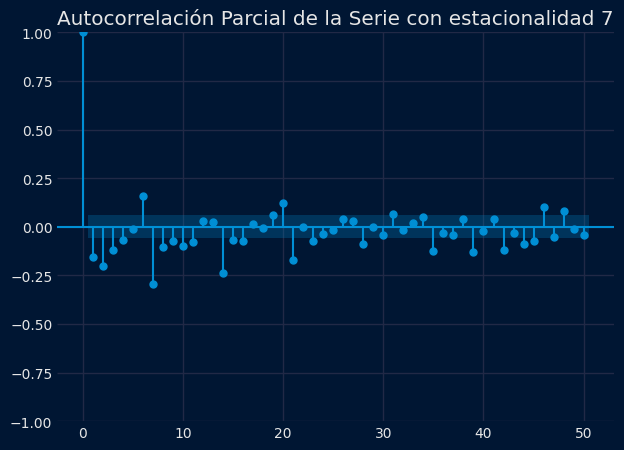

In [17]:
#Autocorrelación de la serie estacional
plot_pacf(data_diff_7, lags = 50, alpha = 0.05)
plt.title('Autocorrelación Parcial de la Serie con estacionalidad 7')
plt.show()

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
modelo_sarimax = SARIMAX(endog = data_train, exog=exog_train, order = (2, 1, 2), seasonal_order = (2, 1, 3, 7))
modelo_sarimax = modelo_sarimax.fit(disp = 0)
modelo_sarimax.summary()

c:\Users\posad\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                         SARIMAX Results                                         
=================================================================================================
Dep. Variable:                                         y   No. Observations:                  911
Model:             SARIMAX(2, 1, 2)x(2, 1, [1, 2, 3], 7)   Log Likelihood               -6170.562
Date:                                   Mon, 11 May 2026   AIC                          12365.124
Time:                                           14:27:05   BIC                          12422.793
Sample:                                       01-02-2019   HQIC                         12387.151
                                            - 06-30-2021                                         
Covariance Type:                                     opg                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
pandemia         4.3461    286.075      0.015      0.988    -556.352     565.044
recuperacion   380.1395    255.547      1.488      0.137    -120.723     881.002
ar.L1           -0.0560      0.241     -0.232      0.816      -0.528       0.416
ar.L2            0.0238      0.136      0.176      0.860      -0.242       0.289
ma.L1           -0.2178      0.239     -0.911      0.363      -0.687       0.251
ma.L2           -0.2422      0.197     -1.231      0.218      -0.628       0.144
ar.S.L7         -0.5971      0.359     -1.663      0.096      -1.301       0.107
ar.S.L14         0.3323      0.240      1.387      0.165      -0.137       0.802
ma.S.L7          0.0610      0.361      0.169      0.866      -0.646       0.768
ma.S.L14        -0.8113      0.382     -2.123      0.034      -1.560      -0.062
ma.S.L21         0.0200      0.120      0.167      0.867      -0.215       0.255
sigma2        5.156e+04    670.540     76.900      0.000    5.03e+04    5.29e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.18   Jarque-Bera (JB):             81683.75
Prob(Q):                              0.67   Prob(JB):                         0.00
Heteroskedasticity (H):               0.94   Skew:                            -3.11
Prob(H) (two-sided):                  0.60   Kurtosis:                        49.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
pred_sarimax  = modelo_sarimax.get_forecast(steps = len(data_test), exog=exog_test).predicted_mean
pred_sarimax.name = 'predicted_sarimax'
display(pred_sarimax.head(5))

2021-07-01    2136.367704
2021-07-02    2358.797368
2021-07-03    1931.843471
2021-07-04    2087.736621
2021-07-05    2157.683838
Freq: D, Name: predicted_sarimax, dtype: float64

[]

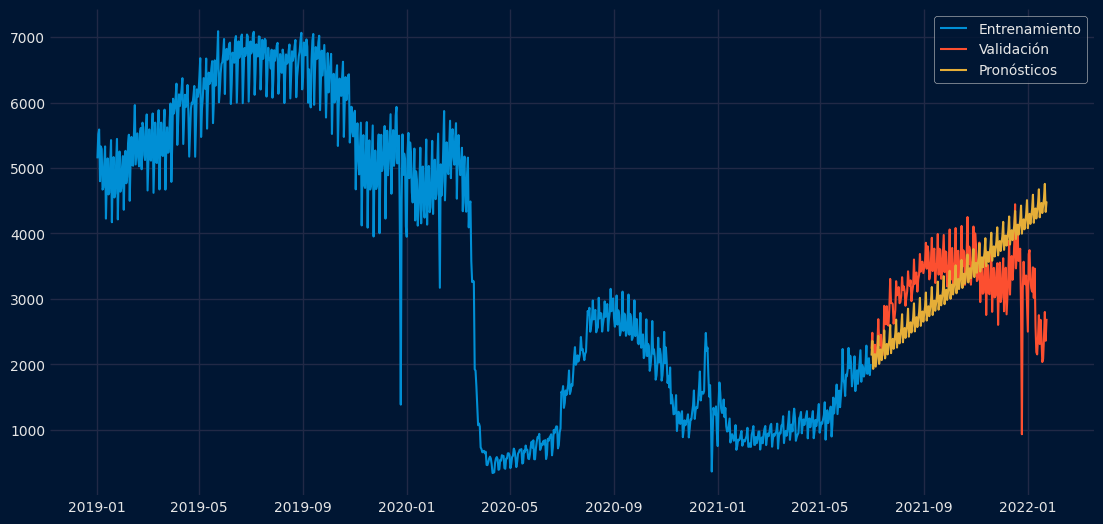

In [20]:
plt.figure(figsize = (12, 6))
plt.plot(data_train, label = 'Entrenamiento')
plt.plot(data_test, label = 'Validación')
plt.plot(pred_sarimax, label = 'Pronósticos')
plt.legend()
plt.plot()

In [21]:
#Forecaster con Machine Learning (Regresión Lineal, Árbol de Decisión, Bosque Aleatorio)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures
from skforecast.plot import plot_prediction_intervals

c:\Users\posad\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
#Forecaster Recursive - Linear Regression
forecaster_lr = ForecasterRecursive(regressor = LinearRegression(), lags = 50, window_features = RollingFeatures(stats = ['mean'], window_sizes = 20))
forecaster_lr.fit(y = data_train, exog=exog_train, store_in_sample_residuals = True)
forecaster_lr

C:\Users\posad\AppData\Local\Temp\ipykernel_7984\6278102.py:2: FutureWarning: The `regressor` argument is deprecated and will be removed in a future version. Please use `estimator` instead.
  forecaster_lr = ForecasterRecursive(regressor = LinearRegression(), lags = 50, window_features = RollingFeatures(stats = ['mean'], window_sizes = 20))


=================== 
ForecasterRecursive 
=================== 
Estimator: LinearRegression 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50] 
Window features: ['roll_mean_20'] 
Window size: 50 
Series name: y 
Exogenous included: True 
Exogenous names: pandemia, recuperacion 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2019-01-02 00:00:00'), Timestamp('2021-06-30 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False} 
fit_kwargs: {} 
Creation date: 2026-05-11 14:27:06 
Last fit date: 2026-05-11 14:27:06 
Skforecast version: 0.21.0 
Python version: 3.13.3 
Forecaster id: None

In [23]:
pred_forecaster_lr = forecaster_lr.predict(steps = len(data_test), exog=exog_test)
display(pred_forecaster_lr.head(5))

2021-07-01    2134.706090
2021-07-02    2459.842299
2021-07-03    2027.647672
2021-07-04    2211.948366
2021-07-05    2330.226285
Freq: D, Name: pred, dtype: float64

[]

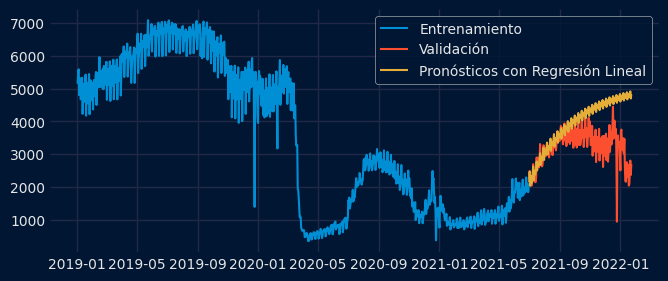

In [24]:
plt.figure(figsize = (7, 3))
plt.plot(data_train, label = 'Entrenamiento')
plt.plot(data_test, label = 'Validación')
plt.plot(pred_forecaster_lr, label = 'Pronósticos con Regresión Lineal')
plt.legend()
plt.plot()

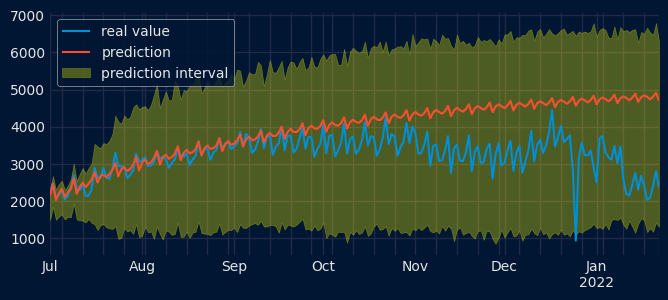

In [25]:
pred_lr_intervals = forecaster_lr.predict_interval(steps = len(data_test) - 1, exog=exog_test, interval = [5, 95], method = 'bootstrapping', n_boot = 100)
plot_prediction_intervals(predictions = pred_lr_intervals, y_true = data_test, target_variable = 'y', kwargs_fill_between = {'color':'yellow', 'alpha':0.3})
plt.show()

In [26]:
forecaster_dt = ForecasterRecursive(regressor = DecisionTreeRegressor(random_state = 123), lags = 15, window_features = RollingFeatures(stats = ['mean'], window_sizes = 10))
forecaster_dt.fit(y = data_train, exog=exog_train, store_in_sample_residuals = True)
forecaster_dt

C:\Users\posad\AppData\Local\Temp\ipykernel_7984\4022462893.py:1: FutureWarning: The `regressor` argument is deprecated and will be removed in a future version. Please use `estimator` instead.
  forecaster_dt = ForecasterRecursive(regressor = DecisionTreeRegressor(random_state = 123), lags = 15, window_features = RollingFeatures(stats = ['mean'], window_sizes = 10))


=================== 
ForecasterRecursive 
=================== 
Estimator: DecisionTreeRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] 
Window features: ['roll_mean_10'] 
Window size: 15 
Series name: y 
Exogenous included: True 
Exogenous names: pandemia, recuperacion 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2019-01-02 00:00:00'), Timestamp('2021-06-30 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None,
    'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf':
    0.0, 'monotonic_cst': None, 'random_state': 123, 'splitter': 'best'} 
fit_kwargs: {} 
Creation date: 2026-05-11 14:27:06 
Last fit date: 2026-05-11 14:27:06 
Skforecast version: 0.21.0 
Python version: 3.13.3 
Forecaster id: None

In [27]:
pred_forecaster_dt = forecaster_dt.predict(steps = len(data_test), exog=exog_test,)
display(pred_forecaster_dt.head(5))

2021-07-01    2012.0
2021-07-02    2124.0
2021-07-03    1837.0
2021-07-04    2223.0
2021-07-05    2012.0
Freq: D, Name: pred, dtype: float64

[]

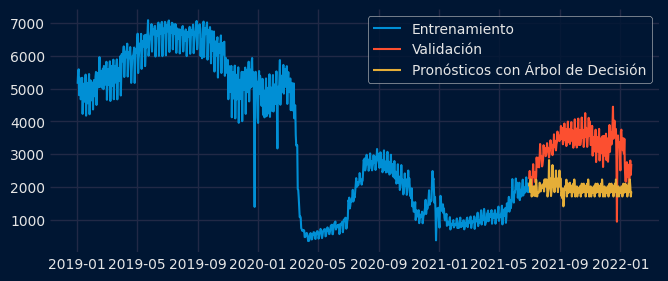

In [28]:
plt.figure(figsize = (7, 3))
plt.plot(data_train, label = 'Entrenamiento')
plt.plot(data_test, label = 'Validación')
plt.plot(pred_forecaster_dt, label = 'Pronósticos con Árbol de Decisión')
plt.legend()
plt.plot()

In [29]:
from skforecast.model_selection import grid_search_forecaster, random_search_forecaster, TimeSeriesFold
#Búsqueda de la ventana temporal para el modelo supervisado
lags_grid = {'lags_1':3, 'lags_2':10, 'lags_3':15, 'lags_4':[1, 2, 3, 12]}
#Búsqueda de hiperparámteros del estimador(regresor)
param_grid = {'max_depth':[5, 10, 20], 'criterion':['squared_error', 'absolute_error', 'poisson', 'friedman_mse']}
#Folds
cv = TimeSeriesFold(steps = 12, initial_train_size = len(data_test))
#Implementación de la búsqueda del predictor
results_forecaster_dt = grid_search_forecaster(forecaster = forecaster_dt, y = data_train, exog=exog_train, param_grid = param_grid,
                                              lags_grid = lags_grid, cv = cv, metric = 'mean_squared_error', return_best = True,
                                              n_jobs = -1, verbose = False, show_progress = True)
results_forecaster_dt

lags grid: 100%|██████████| 4/4 [00:09<00:00,  2.30s/it]


,lags,lags_label,params,mean_squared_error,criterion,max_depth
0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",lags_3,"{'criterion': 'poisson', 'max_depth': 10}",5.402528e+06,poisson,10
1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",lags_3,"{'criterion': 'squared_error', 'max_depth': 10}",5.405505e+06,squared_error,10
2,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 10}",5.405505e+06,friedman_mse,10
3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",lags_3,"{'criterion': 'poisson', 'max_depth': 20}",5.405902e+06,poisson,20
4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",lags_3,"{'criterion': 'squared_error', 'max_depth': 20}",5.407564e+06,squared_error,20
5,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 20}",5.407564e+06,friedman_mse,20
6,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",lags_3,"{'criterion': 'absolute_error', 'max_depth': 20}",5.410657e+06,absolute_error,20
7,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",lags_3,"{'criterion': 'absolute_error', 'max_depth': 10}",5.413304e+06,absolute_error,10
8,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'poisson', 'max_depth': 5}",5.464112e+06,poisson,5
9,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'squared_error', 'max_depth': 5}",5.464112e+06,squared_error,5


In [30]:
forecaster_dt

=================== 
ForecasterRecursive 
=================== 
Estimator: DecisionTreeRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] 
Window features: ['roll_mean_10'] 
Window size: 15 
Series name: y 
Exogenous included: True 
Exogenous names: pandemia, recuperacion 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2019-01-02 00:00:00'), Timestamp('2021-06-30 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'ccp_alpha': 0.0, 'criterion': 'poisson', 'max_depth': 10, 'max_features':
    None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf':
    0.0, 'monotonic_cst': None, 'random_state': 123, 'splitter': 'best'} 
fit_kwargs: {} 
Creation date: 2026-05-11 14:27:06 
Last fit date: 2026-05-11 14:27:15 
Skforecast version: 0.21.0 
Python version: 3.13.3 
Forecaster id: None

[]

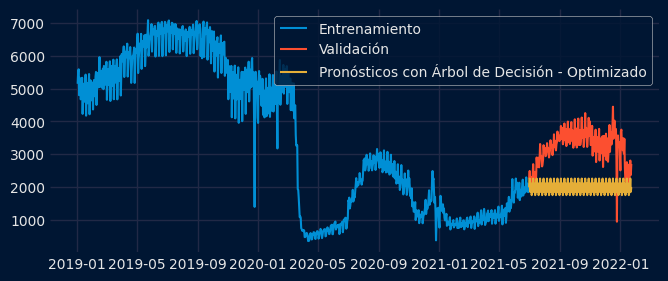

In [31]:
pred_forecaster_dt = forecaster_dt.predict(len(data_test), exog=exog_test)
plt.figure(figsize = (7, 3))
plt.plot(data_train, label = 'Entrenamiento')
plt.plot(data_test, label = 'Validación')
plt.plot(pred_forecaster_dt, label = 'Pronósticos con Árbol de Decisión - Optimizado')
plt.legend()
plt.plot()

In [33]:
forecaster_rf = ForecasterRecursive(regressor = RandomForestRegressor(random_state = 123), lags = 15, window_features = RollingFeatures(stats = ['mean'], window_sizes = 10))
#Búsqueda de la ventana temporal para el modelo supervisado
lags_grid = {'lags_1':3, 'lags_2':10, 'lags_3':[1, 2, 3, 12]}
#Búsqueda de hiperparámteros del estimador(regresor)
param_grid = {'max_depth':[5, 10, 20], 'criterion':['squared_error', 'absolute_error', 'poisson', 'friedman_mse'], 'n_estimators':[100, 200, 300]}
#Folds
cv = TimeSeriesFold(steps = 12, initial_train_size = len(data_test))
#Implementación de la búsqueda del predictor
results_forecaster_rf = grid_search_forecaster(forecaster = forecaster_rf, y = data_train, exog=exog_train, param_grid = param_grid,
                                              lags_grid = lags_grid, cv = cv, metric = 'mean_squared_error', return_best = True,
                                              n_jobs = -1, verbose = False, show_progress = True)
results_forecaster_rf

C:\Users\posad\AppData\Local\Temp\ipykernel_7984\750250771.py:1: FutureWarning: The `regressor` argument is deprecated and will be removed in a future version. Please use `estimator` instead.
  forecaster_rf = ForecasterRecursive(regressor = RandomForestRegressor(random_state = 123), lags = 15, window_features = RollingFeatures(stats = ['mean'], window_sizes = 10))
lags grid: 100%|██████████| 3/3 [03:26<00:00, 68.68s/it]


,lags,lags_label,params,mean_squared_error,criterion,max_depth,n_estimators
0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'absolute_error', 'max_depth': 2...",6.108967e+06,absolute_error,20,200
1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'absolute_error', 'max_depth': 1...",6.109035e+06,absolute_error,10,200
2,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'absolute_error', 'max_depth': 5...",6.151600e+06,absolute_error,5,200
3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'absolute_error', 'max_depth': 1...",6.155895e+06,absolute_error,10,300
4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",lags_2,"{'criterion': 'absolute_error', 'max_depth': 2...",6.155920e+06,absolute_error,20,300
...,...,...,...,...,...,...,...
103,"[1, 2, 3, 12]",lags_3,"{'criterion': 'poisson', 'max_depth': 10, 'n_e...",9.769368e+06,poisson,10,100
104,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 20,...",9.844569e+06,friedman_mse,20,100
105,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 20...",9.844569e+06,squared_error,20,100
106,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 10...",9.859318e+06,squared_error,10,100


[]

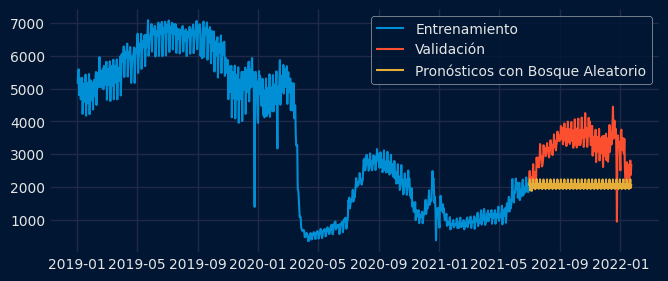

In [ ]:
pred_forecaster_rf = forecaster_rf.predict(len(data_test), exog=exog_test)
plt.figure(figsize = (7, 3))
plt.plot(data_train, label = 'Entrenamiento')
plt.plot(data_test, label = 'Validación')
plt.plot(pred_forecaster_rf, label = 'Pronósticos con Bosque Aleatorio')
plt.legend()
plt.plot()

In [ ]:
%pip install tensorflow -q
%pip install keras -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#Librerías
import pandas as pd
from dateutil.relativedelta import relativedelta
from skforecast.deep_learning import ForecasterRnn, create_and_compile_model
from skforecast.model_selection import backtesting_forecaster_multiseries
from keras.optimizers import Adam
from keras.losses import MeanSquaredError

In [ ]:
from dateutil.relativedelta import relativedelta

# Redes Neuronales Recurrentes (LSTM y GRU)
# Construir los conjuntos de entrenamiento, validación y prueba (70, 20 y 10)

end_train = data.index[0] + relativedelta(months=26)
end_validation = end_train + relativedelta(months=7)

# Variable objetivo
data_train_rnn = data['y'].loc[:end_train]
data_val_rnn = data['y'].loc[(data['y'].index > end_train) & (data['y'].index <= end_validation)]
data_test_rnn = data['y'].loc[data['y'].index > end_validation]

# Variables exógenas
exog_train_rnn = data.loc[data_train_rnn.index, ['pandemia', 'recuperacion']]
exog_val_rnn = data.loc[data_val_rnn.index, ['pandemia', 'recuperacion']]
exog_test_rnn = data.loc[data_test_rnn.index, ['pandemia', 'recuperacion']]

print(f"Fechas de Entrenamiento: {data_train_rnn.index.min()} -- {data_train_rnn.index.max()} -- n = {len(data_train_rnn)}")
print(f"Fechas de Validación: {data_val_rnn.index.min()} -- {data_val_rnn.index.max()} -- n = {len(data_val_rnn)}")
print(f"Fechas de Prueba: {data_test_rnn.index.min()} -- {data_test_rnn.index.max()} -- n = {len(data_test_rnn)}")

print("Exog train:", exog_train_rnn.shape)
print("Exog val:", exog_val_rnn.shape)
print("Exog test:", exog_test_rnn.shape)

Fechas de Entrenamiento: 2019-01-02 00:00:00 -- 2021-03-02 00:00:00 -- n = 791
Fechas de Validación: 2021-03-03 00:00:00 -- 2021-10-02 00:00:00 -- n = 214
Fechas de Prueba: 2021-10-03 00:00:00 -- 2022-01-23 00:00:00 -- n = 113
Exog train: (791, 2)
Exog val: (214, 2)
Exog test: (113, 2)


[]

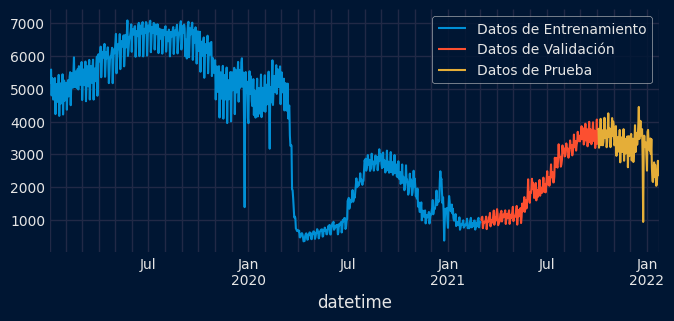

In [ ]:
plt.figure(figsize = (7, 3))
data_train_rnn.plot(label = 'Datos de Entrenamiento')
data_val_rnn.plot(label = 'Datos de Validación')
data_test_rnn.plot(label = 'Datos de Prueba')
plt.legend()
plt.plot()

In [ ]:
#Modelo LSTM
lags = 24
model_lstm = create_and_compile_model(series = pd.DataFrame(data['y']),
                                      exog=data[['pandemia', 'recuperacion']],
                                      levels = ['y'],
                                      lags = lags,
                                      steps = 1,
                                      recurrent_layer = 'LSTM',
                                      recurrent_units = [64],
                                      recurrent_layers_kwargs = {'activation':'tanh'},
                                      dense_units = [32],
                                      compile_kwargs = {'optimizer':Adam(),
                                                        'loss':MeanSquaredError()})
model_lstm.summary()

keras version: 3.14.0
Using backend: tensorflow
tensorflow version: 2.21.0



Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ series_input        │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     16,896 │ series_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 1, 64)     │          0 │ lstm_1[0][0]      │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exog_input          │ (None, 1, 2)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_exog         │ (None, 1, 66)     │          0 │ repeat_vector[0]… │
│ (Concatenate)       │                   │            │ exog_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_td_1          │ (None, 1, 32)     │      2,144 │ concat_exog[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense_td_la… │ (None, 1, 1)      │         33 │ dense_td_1[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,073 (74.50 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
forecaster_lstm = ForecasterRnn(regressor = model_lstm,
                                levels = ['y'],
                                
                                lags = lags,
                                transformer_series = MinMaxScaler(),
                                fit_kwargs = {'epochs':500,
                                              'batch_size':512,
                                              'series_val':pd.DataFrame(data_val_rnn),
                                              'exog_val': exog_val_rnn})
forecaster_lstm.fit(pd.DataFrame(data_train_rnn), exog=exog_train_rnn)

Epoch 1/500


C:\Users\posad\AppData\Local\Temp\ipykernel_24536\3529008020.py:1: FutureWarning: The `regressor` argument is deprecated and will be removed in a future version. Please use `estimator` instead.
  forecaster_lstm = ForecasterRnn(regressor = model_lstm,
c:\Users\posad\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 16 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 360ms/step - loss: 0.3971 - val_loss: 0.0823
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.3059 - val_loss: 0.0597
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.2307 - val_loss: 0.0419
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.1727 - val_loss: 0.0241
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.1105 - val_loss: 0.0092
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0548 - val_loss: 0.0055
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0286 - val_loss: 0.0207
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0497 - val_loss: 0.0264
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0507 - val_loss: 0.0148
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0259 - val_loss: 0.0056
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0149 - val_loss: 0.0027
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0172 - val_loss: 0.0029


In [ ]:
forecaster_lstm

============= 
ForecasterRnn 
============= 
Estimator: <Functional name=functional_4, built=True> 
Layers names: ['series_input', 'lstm_1', 'repeat_vector', 'exog_input', 'concat_exog', 'dense_td_1', 'output_dense_td_layer'] 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24] 
Window size: 24 
Maximum steps to predict: [1] 
Series names: y 
Target series (levels): ['y'] 
Exogenous included: True 
Exogenous names: pandemia, recuperacion 
Transformer for series: MinMaxScaler() 
Transformer for exog: MinMaxScaler() 
Training range: [Timestamp('2019-01-02 00:00:00'), Timestamp('2021-03-02 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: {'name': 'functional_4', 'trainable': True, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 24, 1), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'series_input', 'optional': False}, 'registered_name': None, 'name': 'series_input', 'inbound_nodes': []}, {'module': 'keras.layers', 'class_name': 'LSTM', 'config': {'name': 'lstm_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'return_sequences': False, 'return_state': False, 'go_backwards': False, 'stateful': False, 'unroll': False, 'zero_output_for_mask': False, 'units': 64, 'activation': 'tanh', 'recurrent_activation': 'sigmoid', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'recurrent_initializer': {'module': 'keras.initializers', 'class_name': 'Orthogonal', 'config': {'seed': None, 'gain': 1.0}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'unit_forget_bias': True, 'kernel_regularizer': None, 'recurrent_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'recurrent_constraint': None, 'bias_constraint': None, 'dropout': 0.0, 'recurrent_dropout': 0.0, 'seed': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 24, 1]}, 'name': 'lstm_1', 'inbound_nodes': [{'args': ({'class_name': '__keras_tensor__', 'config': {'shape': (None, 24, 1), 'dtype': 'float32', 'keras_history': ['series_input', 0, 0]}},), 'kwargs': {'training': False, 'mask': None}}]}, {'module': 'keras.layers', 'class_name': 'RepeatVector', 'config': {'name': 'repeat_vector', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'n': 1}, 'registered_name': None, 'build_config': {'input_shape': [None, 64]}, 'name': 'repeat_vector', 'inbound_nodes': [{'args': ({'class_name': '__keras_tensor__', 'config': {'shape': (None, 64), 'dtype': 'float32', 'keras_history': ['lstm_1', 0, 0]}},), 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 1, 2), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'exog_input', 'optional': False}, 'registered_name': None, 'name': 'exog_input', 'inbound_nodes': []}, {'module': 'keras.layers', 'class_name': 'Concatenate', 'config': {'name': 'concat_exog', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'axis': -1}, 'registered_name': None, 'build_config': {'input_shape': [[None, 1, 64], [None, 1, 2]]}, 'name': 'concat_exog', 'inbound_nodes': [{'args': ([{'class_name': '__keras_tensor__', 'config': {'shape': (None, 1, 64), 'dtype': 'float32', 'keras_history': ['repeat_vector', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': (None, 1, 2), 'dtype': 'float32', 'keras_history': ['exog_input', 0, 0]}}],), 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'TimeDistributed', 'config': {'name': 'dense_td_1', 'trainable

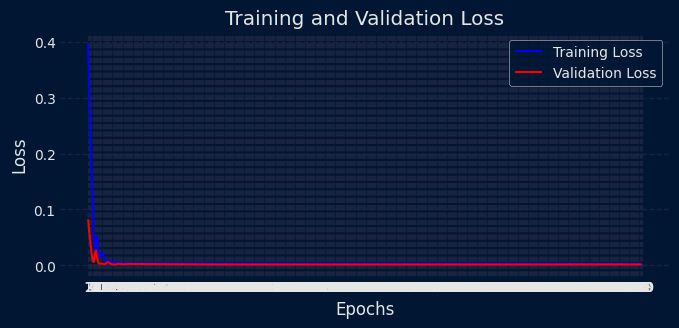

In [ ]:
fig, ax = plt.subplots(figsize = (7, 3))
plot = forecaster_lstm.plot_history(ax = ax)

In [ ]:
#Backtesting de la red neuronal
cv = TimeSeriesFold(steps = forecaster_lstm.max_step,
                    initial_train_size = len(data.loc[:end_validation, :]),
                    refit = False)
forecaster_lstm.set_fit_kwargs({'epochs':15, 'batch_size':512})
metrics, predictions = backtesting_forecaster_multiseries(forecaster = forecaster_lstm,
                                                          series = data[['y']],
                                                          exog=data[['pandemia', 'recuperacion']],
                                                          cv = cv,
                                                          levels = forecaster_lstm.levels,
                                                          metric = 'mean_absolute_error',
                                                          verbose = False)

Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0027 
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0027
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0027
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0027
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0027
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0027
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0027
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0026
Epoch 9/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0026
Epoch 10/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0026
Epoch 11/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0026
Epoch 12/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0026
Epoch 13/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0026
Epoch 14/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0026
Epoch 15/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0026


100%|██████████| 113/113 [00:00<00:00, 958.59it/s]


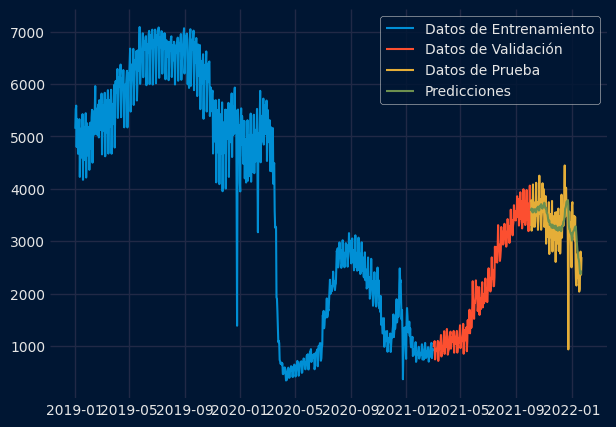

In [ ]:
pred_lstm = predictions[['pred']]
plt.plot(data_train_rnn, label = 'Datos de Entrenamiento')
plt.plot(data_val_rnn, label = 'Datos de Validación')
plt.plot(data_test_rnn, label = 'Datos de Prueba')
plt.plot(pred_lstm, label = 'Predicciones')
plt.legend()
plt.show()

In [ ]:
#Modelo GRU
lags = 24
model_gru = create_and_compile_model(series = pd.DataFrame(data['y']),
                                      levels = ['y'],
                                      exog=data[['pandemia', 'recuperacion']],
                                      lags = lags,
                                      steps = 1,
                                      recurrent_layer = 'GRU',
                                      recurrent_units = [64],
                                      recurrent_layers_kwargs = {'activation':'tanh'},
                                      dense_units = [32],
                                      compile_kwargs = {'optimizer':Adam(),
                                                        'loss':MeanSquaredError()})
model_gru.summary()

keras version: 3.14.0
Using backend: tensorflow
tensorflow version: 2.21.0



Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ series_input        │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 64)        │     12,864 │ series_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 1, 64)     │          0 │ gru_1[0][0]       │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exog_input          │ (None, 1, 2)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_exog         │ (None, 1, 66)     │          0 │ repeat_vector[0]… │
│ (Concatenate)       │                   │            │ exog_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_td_1          │ (None, 1, 32)     │      2,144 │ concat_exog[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense_td_la… │ (None, 1, 1)      │         33 │ dense_td_1[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,041 (58.75 KB)

 Trainable params: 15,041 (58.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
forecaster_gru = ForecasterRnn(regressor = model_gru,
                                levels = ['y'],
                                lags = lags,
                                transformer_series = MinMaxScaler(),
                                fit_kwargs = {'epochs':500,
                                              'batch_size':512,
                                              'series_val':pd.DataFrame(data_val_rnn),
                                              'exog_val': exog_val_rnn})
forecaster_gru.fit(pd.DataFrame(data_train_rnn), exog=exog_train_rnn)

Epoch 1/500


C:\Users\posad\AppData\Local\Temp\ipykernel_24536\3047186841.py:1: FutureWarning: The `regressor` argument is deprecated and will be removed in a future version. Please use `estimator` instead.
  forecaster_gru = ForecasterRnn(regressor = model_gru,
c:\Users\posad\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 16 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 365ms/step - loss: 0.4108 - val_loss: 0.0796
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.3223 - val_loss: 0.0569
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.2486 - val_loss: 0.0377
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.1828 - val_loss: 0.0230
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.1269 - val_loss: 0.0123
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0832 - val_loss: 0.0062
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0491 - val_loss: 0.0052
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0250 - val_loss: 0.0099
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0145 - val_loss: 0.0194
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0146 - val_loss: 0.0298
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0205 - val_loss: 0.0351
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0232 - val_loss: 0.0330


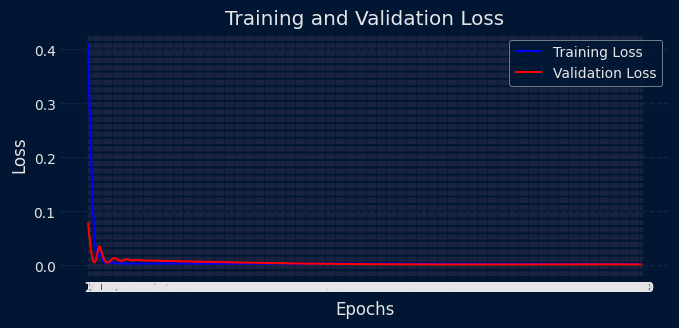

In [ ]:
fig, ax = plt.subplots(figsize = (7, 3))
plot = forecaster_gru.plot_history(ax = ax)

In [ ]:
#Backtesting de la red neuronal
cv = TimeSeriesFold(steps = forecaster_gru.max_step,
                    initial_train_size = len(data.loc[:end_validation, :]),
                    refit = False)
forecaster_gru.set_fit_kwargs({'epochs':15, 'batch_size':512})
metrics, predictions = backtesting_forecaster_multiseries(forecaster = forecaster_gru,
                                                          series = data[['y']],
                                                          exog=data[['pandemia', 'recuperacion']],
                                                          cv = cv,
                                                          levels = forecaster_gru.levels,
                                                          metric = 'mean_absolute_error',
                                                          verbose = False)

Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0025 
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0025 
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0024
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0024
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0024
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0023
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0023
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0023
Epoch 9/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0023
Epoch 10/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0023
Epoch 11/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0023
Epoch 12/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0023
Epoch 13/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0023
Epoch 14/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0023
Epoch 15/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0023


100%|██████████| 113/113 [00:00<00:00, 1175.48it/s]


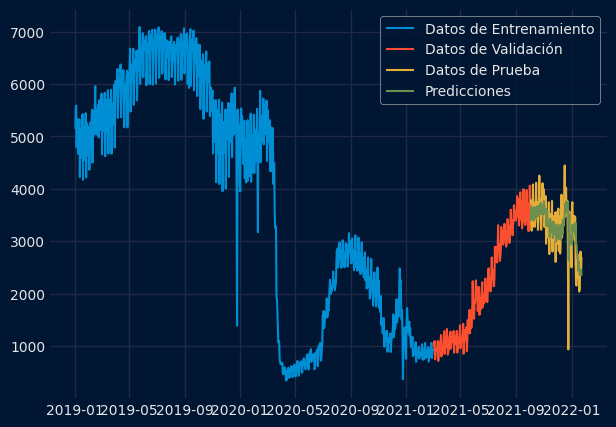

In [ ]:
pred_gru = predictions[['pred']]
plt.plot(data_train_rnn, label = 'Datos de Entrenamiento')
plt.plot(data_val_rnn, label = 'Datos de Validación')
plt.plot(data_test_rnn, label = 'Datos de Prueba')
plt.plot(pred_gru, label = 'Predicciones')
plt.legend()
plt.show()

# Evaluacion de Modelos - Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error

# Alinear LSTM y GRU por longitud
data_test_lstm = data_test_rnn.iloc[-len(pred_lstm):]
data_test_gru = data_test_rnn.iloc[-len(pred_gru):]

print(f"El MAE para SARIMAX es: {round(mean_absolute_error(data_test, pred_sarimax), 2)} y el MAPE para SARIMAX es: {round(mean_absolute_percentage_error(data_test, pred_sarimax), 4) * 100}%")

print(f"El MAE para Regresión Lineal es: {round(mean_absolute_error(data_test, pred_forecaster_lr), 2)} y el MAPE para Regresión Lineal es: {round(mean_absolute_percentage_error(data_test, pred_forecaster_lr), 4) * 100}%")

print(f"El MAE para Árbol de Decisión es: {round(mean_absolute_error(data_test, pred_forecaster_dt), 2)} y el MAPE para Árbol de Decisión es: {round(mean_absolute_percentage_error(data_test, pred_forecaster_dt), 4) * 100}%")

print(f"El MAE para Bosque Aleatorio es: {round(mean_absolute_error(data_test, pred_forecaster_rf), 2)} y el MAPE para Bosque Aleatorio es: {round(mean_absolute_percentage_error(data_test, pred_forecaster_rf), 4) * 100}%")

print(f"El MAE para LSTM es: {round(mean_absolute_error(data_test_lstm, pred_lstm), 2)} y el MAPE para LSTM es: {round(mean_absolute_percentage_error(data_test_lstm, pred_lstm), 4) * 100}%")

print(f"El MAE para GRU es: {round(mean_absolute_error(data_test_gru, pred_gru), 2)} y el MAPE para GRU es: {round(mean_absolute_percentage_error(data_test_gru, pred_gru), 4) * 100}%")

El MAE para SARIMAX es: 626.93 y el MAPE para SARIMAX es: 21.93%
El MAE para Regresión Lineal es: 736.44 y el MAPE para Regresión Lineal es: 25.840000000000003%
El MAE para Árbol de Decisión es: 1260.77 y el MAPE para Árbol de Decisión es: 38.01%
El MAE para Bosque Aleatorio es: 1184.36 y el MAPE para Bosque Aleatorio es: 35.52%
El MAE para LSTM es: 309.91 y el MAPE para LSTM es: 11.799999999999999%
El MAE para GRU es: 303.43 y el MAPE para GRU es: 11.26%


- GRU is the best model with the smallest error (11.26%)
- GRU es el modelo con menor error (11.26%)